In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dataset=pd.read_csv("/content/sample_data/train.csv")


In [2]:
print("Missing Values")
print(dataset.isnull().sum())

Missing Values
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [4]:
print("Filling Missing Value of Age with its median ")
dataset['Age']=dataset["Age"].fillna(dataset["Age"].median())
print(dataset.isnull().sum())

Filling Missing Value of Age with its median 
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [9]:
print("Filling Missing Embarked Value with Mode since it is a categorical data")
dataset['Embarked']=dataset['Embarked'].fillna(dataset['Embarked'].mode()[0])

# Drop Cabin because of too many missing values
dataset = dataset.drop(columns=["Cabin"])
print(dataset.isnull().sum())

Filling Missing Embarked Value with Mode since it is a categorical data
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


I've used fillna() to fill value in Age using median as it is a numerical data and Emarked using mode as it is a categorical data. I used dropna() to drop the Cabin column due to large number of missing values

Histogram


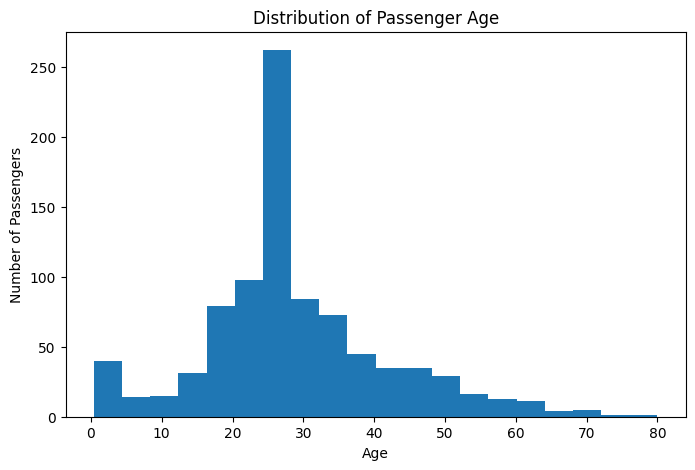

In [17]:
print("Histogram")
plt.figure(figsize=(8,5))
plt.hist(dataset["Age"],bins=20)
plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

Histogram


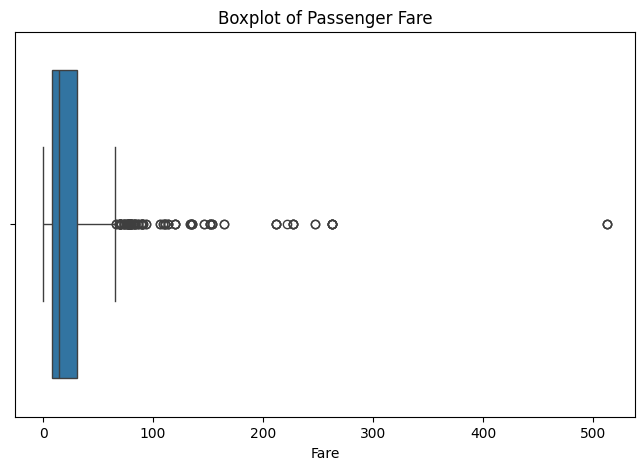

In [20]:
print("Histogram")
plt.figure(figsize=(8, 5))

sns.boxplot(x=dataset["Fare"])

plt.title("Boxplot of Passenger Fare")
plt.xlabel("Fare")

plt.show()


### Outlier Detection

I used a boxplot to detect outliers in the `Fare` column.
The boxplot shows several values above the upper whisker, indicating
that some passengers paid unusually high fares compared with most passengers.

Bar Chart


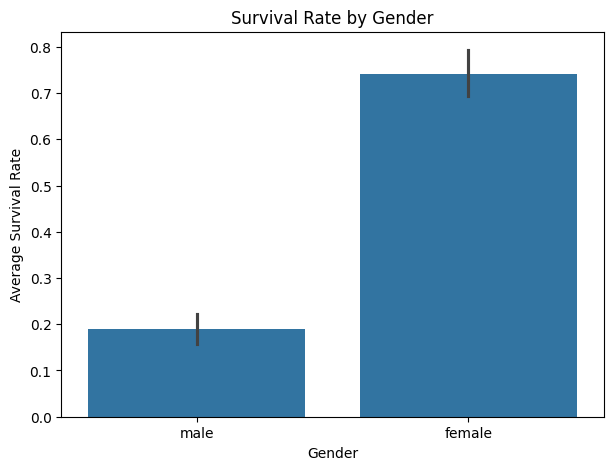

In [22]:
print("Bar Chart")
plt.figure(figsize=(7,5))
sns.barplot(x="Sex",
            y="Survived",
            data=dataset)
plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Survival Rate")
plt.show()

HeatMap - Helps to see r/s between numerical variables


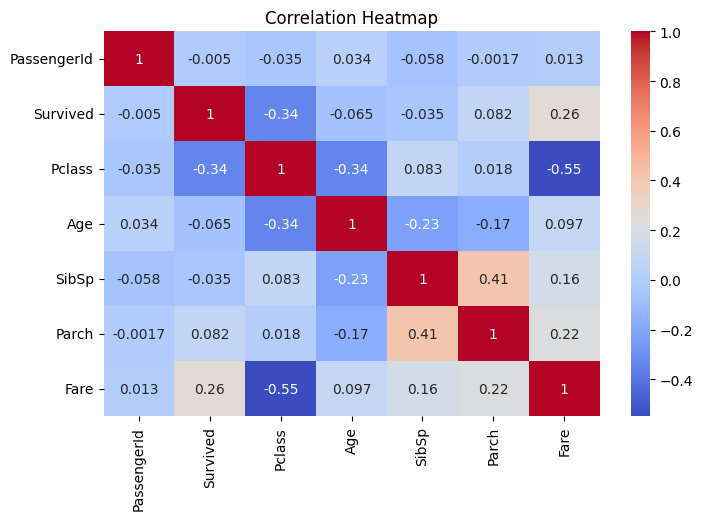

In [23]:
print("HeatMap - Helps to see r/s between numerical variables")
plt.figure(figsize=(8,5))
correlation=dataset.select_dtypes(include="number").corr()
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

### Which feature do you think most affects survival, and why?

I think **Sex** is the features that most affects survival as the survival rate for female passengers was much higher than for male passengers. This suggests that female were given priority.

Another important feature is **Pclass**. Passengers in higher classes
generally had better survival rates than passengers in lower classes.
This may be related to differences in access to lifeboats and other
resources during the disaster.